# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**周毅鹏**  
第5天专题（A/B/C/D/E）：**A**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [33]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012411"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012411
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [34]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均返现,平均距上次下单天数
0,0-6个月,1967,689,0.35,2.47,158.79,3.71
1,6-12个月,1585,157,0.10,2.66,161.48,4.33
2,12-24个月,1574,102,0.06,3.64,200.72,5.24
3,24个月以上,504,0,0.00,3.68,225.30,5.37


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,0-6个月,0,1341,320,0.24,2.42,可观察
1,0-6个月,1,626,369,0.59,2.59,可观察
2,6-12个月,0,1192,74,0.06,2.66,可观察
3,6-12个月,1,393,83,0.21,2.66,可观察
4,12-24个月,1,439,56,0.13,3.27,可观察


检查点1A通过：输入文件有效


In [35]:
# TODO: 填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同用户留存时长分组的流失率对比情况如何？",
    "behavior_scatter": "不同订单数量下，留存与流失用户的返现金额分布存在什么差异？",
    "ordered_line": "随用户留存周期增长，用户平均下单数量呈现怎样变化趋势？",
    "composition_chart": "有无投诉行为的用户，在各留存区间的用户人数占比分布是怎样的？",
}

chart_reasons = {
    "category_bar": "柱状图适合对比不同用户留存时长分组的流失率数值大小，直观展示各组流失率高低差异",
    "behavior_scatter": "散点图可以同时展现订单数量、返现金额两个数值变量，并区分流失/留存两类用户，直观对比两组人群的分布差别",
    "ordered_line": "折线图擅长表现随（时间/周期）变化下指标的连续变化趋势",
    "composition_chart": "构成类图表（饼图/堆叠柱状）用于展示整体内部不同分组的占比结构",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过:业务问题和选择理由已填写")

检查点1B通过:业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [36]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby("TenureGroup", observed=True)
      .agg(
          用户数=("CustomerID", "nunique"),
          流失人数=("Churn", "sum"),
          流失率=("Churn", "mean"),
          平均订单数=("OrderCount", "mean"),
          平均返现=("CashbackAmount", "mean"),
          平均距上次下单天数=("DaySinceLastOrder", "mean"),
      )
      .reset_index()
)
time_order = ["0-6个月", "6-12个月", "12-24个月", "24个月以上"]
category_summary=category_summary.sort_values(
    by="TenureGroup",
    key=lambda x: x.map({val:i for i, val in enumerate(time_order)})
).reset_index(drop=True) 

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均返现,平均距上次下单天数
0,0-6个月,1967,689,0.35,2.47,158.79,3.71
1,6-12个月,1585,157,0.10,2.66,161.48,4.33
2,12-24个月,1574,102,0.06,3.64,200.72,5.24
3,24个月以上,504,0,0.00,3.68,225.30,5.37


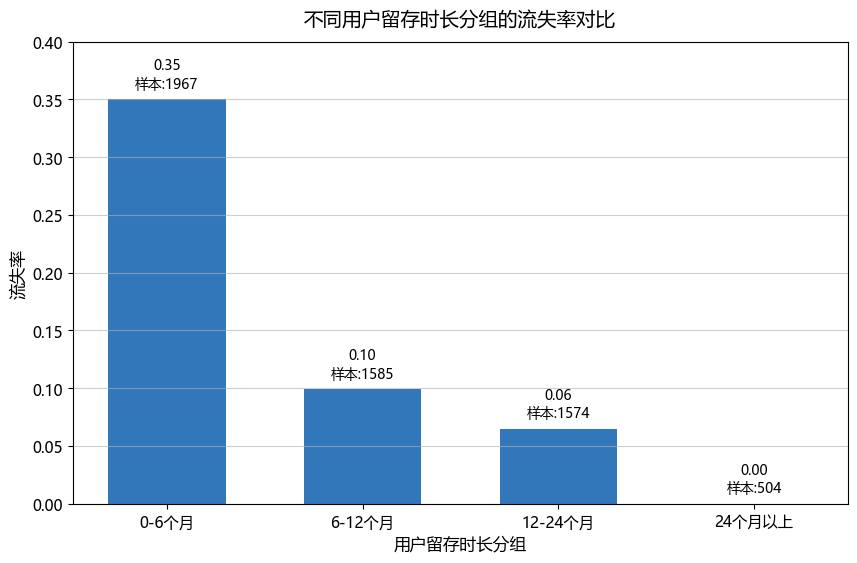

已输出： output\day06_visualization\01_category_bar.png


In [37]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
x=category_summary["TenureGroup"]
y=category_summary["流失率"]
sample_size=category_summary["用户数"]
bars = ax_bar.bar(x,y,width=0.6,color= "#3377bb")
ax_bar.set_title("不同用户留存时长分组的流失率对比",fontsize=14,pad=12)
ax_bar.set_xlabel("用户留存时长分组",fontsize=12)
ax_bar.set_ylabel("流失率",fontsize=12)
ax_bar.set_ylim(0,0.4)
ax_bar.grid(axis="y",alpha=0.6)
for bar,num in zip(bars,sample_size):
    height = bar.get_height()
    ax_bar.text(
        bar.get_x()+bar.get_width()/2,
        height+0.01,
        f"{height:.2f}\n样本:{num}",
        ha="center",fontsize=10
    )

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：用户留存时长和流失率呈现明显负相关关系，用户入驻平台时间越短，流失风险越高；随着使用周期不断拉长，流失率持续走低，使用满 24 个月及以上的用户不存在流失情况，用户粘性极强。
- 证据：0-6 个月新用户样本 1967 人，流失率 0.35，是所有分组里流失风险最高的群体；6-12 个月用户样本 1585 人，流失率下降至 0.10；12-24 个月用户样本 1574 人，流失率仅 0.06；24 个月以上资深用户样本 504 人，流失率为 0。新老用户流失率差距悬殊，新用户与资深用户流失率相差 35 个百分点。
- 边界：该图表仅展示不同周期用户流失率的分布差异，只能证明两者存在相关趋势，无法判定留存时间长是低流失的直接原因；图表仅基于静态截面样本，无法反映长期时序变化；同时没有结合投诉、消费金额等变量，不能排除其他因素对流失率的干扰，无法单独作为因果判断依据。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


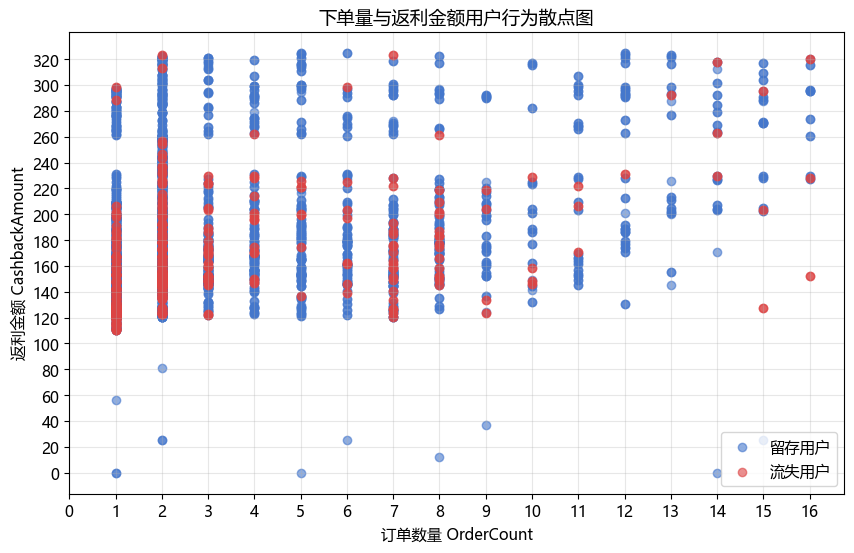

已输出： output\day06_visualization\02_behavior_scatter.png


In [38]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例

# 流失用户Churn=1红色，留存Churn=0蓝色，透明度0.6
churn_0 = df[df["Churn"] == 0]
churn_1 = df[df["Churn"] == 1]
ax_scatter.scatter(churn_0[x_field], churn_0[y_field], c="#4477cc", alpha=0.6, label="留存用户")
ax_scatter.scatter(churn_1[x_field], churn_1[y_field], c="#dd4444", alpha=0.6, label="流失用户")

ax_scatter.set_title("下单量与返利金额用户行为散点图")
ax_scatter.set_xlabel("订单数量 OrderCount")
ax_scatter.set_ylabel("返利金额 CashbackAmount")
ax_scatter.legend()
ax_scatter.set_xticks(np.arange(0, 17, step=1))
ax_scatter.set_yticks(np.arange(0, 330, step=20))
ax_scatter.grid(alpha=0.3)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：订单数量与返利金额整体呈现正向关联；相同下单量下，留存用户可获得的返利金额上限普遍高于流失用户，流失用户大量集中在返利偏低的区间。
- 证据：整体来看，随着订单数量 OrderCount 从 1 增长至 16，用户对应的 CashbackAmount 返利金额整体随之升高；当订单量固定时，蓝色留存用户散点分布区间更广、峰值更高，红色流失用户大多聚集在返利 150 及以下的低位区域；同时存在少量异常点：部分订单量很高的流失用户返利极低，少数低订单量的留存用户也能拿到高额返利。
- 边界：该散点图仅能体现两个变量的相关趋势，无法证明下单量提升是返利增多的直接原因；没有纳入用户留存时长、消费品类等干扰变量，不能排除其他因素对返利、用户流失状态造成的影响，仅可用于描述分布特征，不可推导因果逻辑。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [39]:
TENURE_ORDER = ["0-6个月", "6-12个月", "12-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = df.groupby(ordered_field).agg(
    用户数=("CustomerID", "nunique"),
    平均下单量=("OrderCount", "mean")
).reindex(TENURE_ORDER).reset_index()

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,平均下单量
0,0-6个月,1967,2.47
1,6-12个月,1585,2.66
2,12-24个月,1574,3.64
3,24个月以上,504,3.68


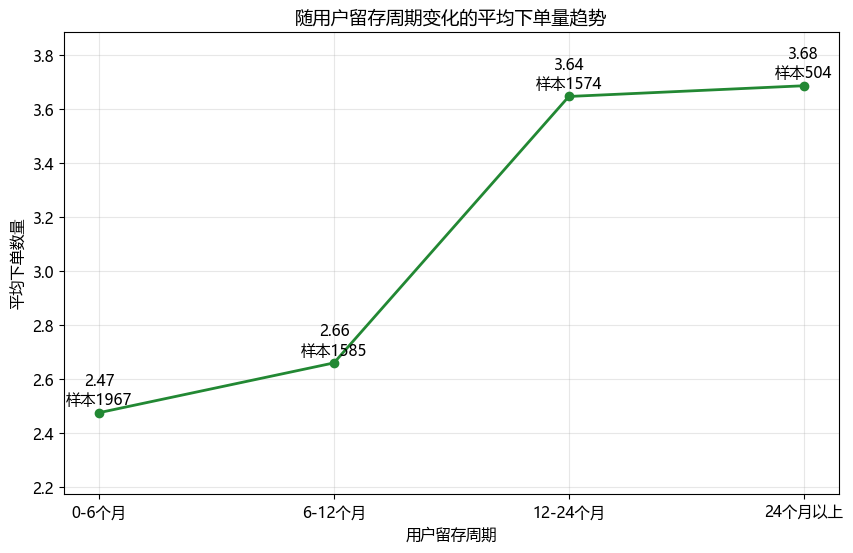

已输出： output\day06_visualization\03_ordered_line.png


In [40]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
ax_line.plot(ordered_summary.index, ordered_summary["平均下单量"], marker="o", linewidth=2, color="#228833")
ax_line.set_xticks(range(len(TENURE_ORDER)))
ax_line.set_xticklabels(TENURE_ORDER)
ax_line.set_xlabel("用户留存周期")
y_min = ordered_summary["平均下单量"].min() - 0.3
y_max = ordered_summary["平均下单量"].max() + 0.2
ax_line.set_ylim(y_min, y_max)
# 标注数值和样本
for i, val in enumerate(ordered_summary["平均下单量"]):
    user_cnt = ordered_summary["用户数"].iloc[i]
    ax_line.text(i, val+0.03, f"{val:.2f}\n样本{user_cnt}", ha="center")

ax_line.set_title("随用户留存周期变化的平均下单量趋势")
ax_line.set_xlabel("用户留存周期")
ax_line.set_ylabel("平均下单数量")
ax_line.grid(alpha=0.3)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：用户平均下单量会随留存周期拉长持续上升，增长幅度在 0-6 个月至 12-24 个月阶段最为明显，24 个月以上用户下单量增速趋近停滞，整体曲线趋于平缓。
- 证据：0-6 个月用户样本 1967 人，平均下单量 2.47；6-12 个月用户样本 1565 人，平均下单量 2.66；12-24 个月用户样本 1574 人，平均下单量 3.64；24 个月以上用户样本 504 人，平均下单量 3.68。0-12 个月下单量小幅上涨，12-24 个月出现大幅提升，24 个月后仅有微小增长。
- 边界：本次对比仅针对用户生命周期有序分段，属于静态截面数据，不能等同于自然月度、年度时间维度的时序变化，无法反映长期时间波动带来的影响。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [41]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
comp_raw = df.groupby(composition_field)["CustomerID"].nunique()
composition_summary = pd.DataFrame({
    composition_field: comp_raw.index,
    "用户数": comp_raw.values,
    "占比": (comp_raw / comp_raw.sum()).values
})
time_order = ["0-6个月", "6-12个月", "12-24个月", "24个月以上"]
composition_summary=composition_summary.sort_values(
    by="TenureGroup",
    key=lambda x: x.map({val:i for i, val in enumerate(time_order)})
).reset_index(drop=True)

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,TenureGroup,用户数,占比
0,0-6个月,1967,0.35
1,6-12个月,1585,0.28
2,12-24个月,1574,0.28
3,24个月以上,504,0.09


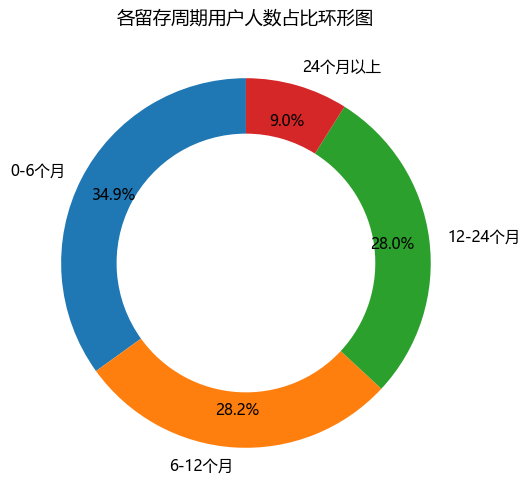

已输出： output\day06_visualization\04_composition_chart.png


In [42]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
wedges, texts, autotexts = ax_composition.pie(
    composition_summary["用户数"],
    labels=composition_summary[composition_field],
    autopct="%1.1f%%",
    pctdistance=0.8,
    wedgeprops={"width":0.3}, # 设置环形宽度
    startangle=90
)
ax_composition.set_title("各留存周期用户人数占比环形图")

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：电商用户按照留存周期划分后，新留存用户（0-6 个月）占比最高，随着使用时长增加，中长期用户整体占比逐步缩减，使用超过 24 个月的老用户群体规模最小。
- 证据：0-6 个月用户占比 34.9%，6-12 个月用户占比 28.2%，12-24 个月用户占比 28.0%，24 个月以上用户占比仅 9.0%。前三个周期用户体量差距不大，合计占据九成以上用户。
- 边界：环形图适合对比各分组在整体中的份额大小，直观展示内部结构；但不适合精准对比组别间微小差值，也无法用于跨时间段、跨群体的横向对比，仅能呈现当前静态整体结构。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [43]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


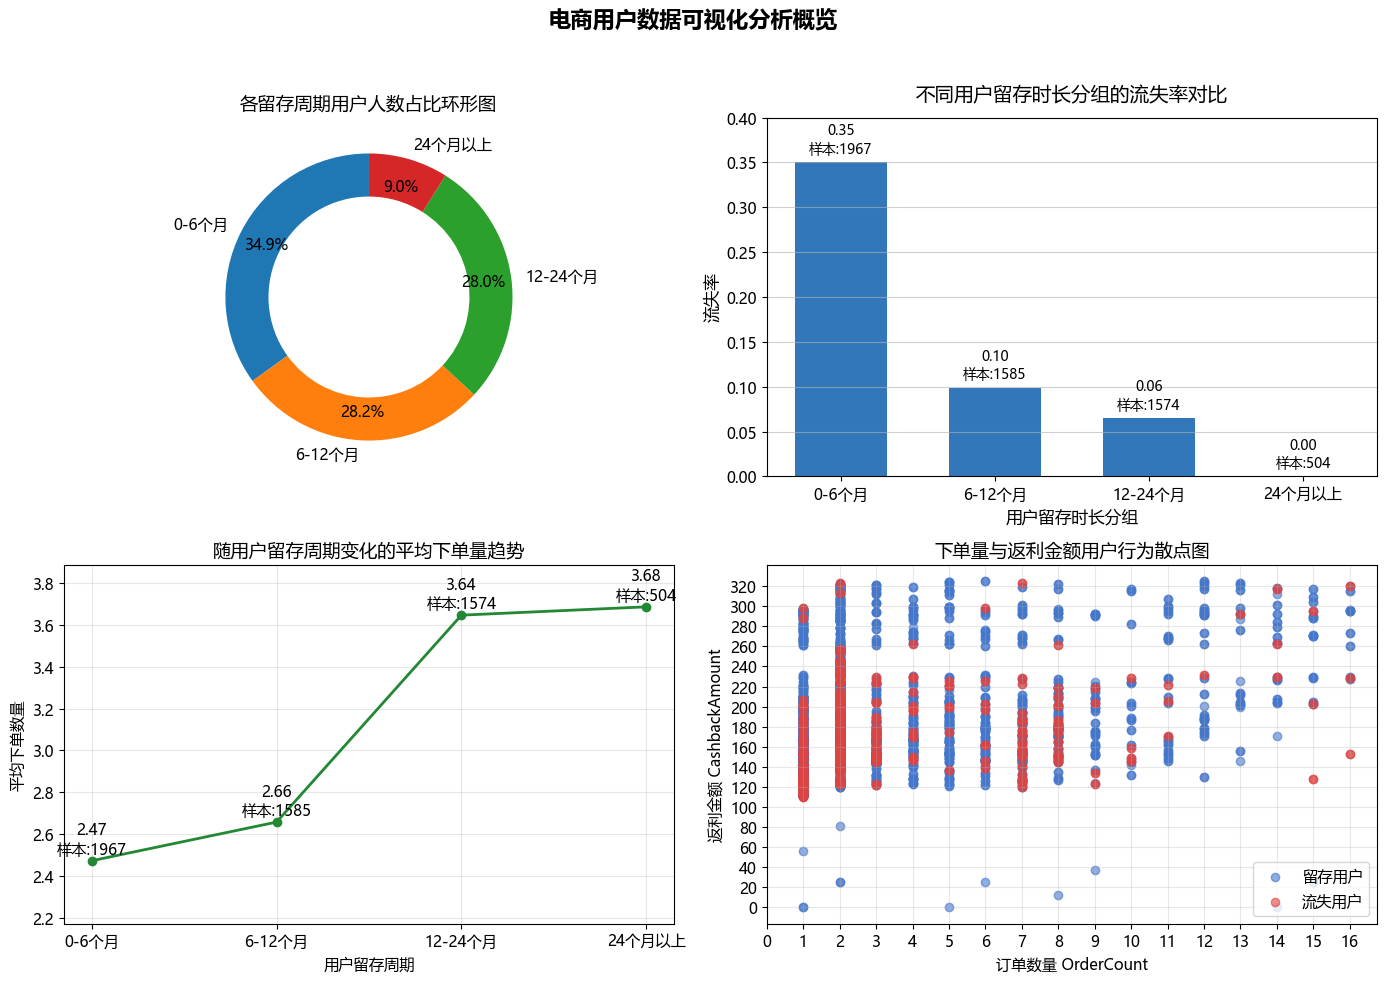

已输出： output\day06_visualization\day06_visualization_summary.png


In [44]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图

# ====================== 左上axes[0,0]：环形图 原composition绘图代码 ======================
wedges, texts, autotexts = axes[0,0].pie(
    composition_summary["用户数"],
    labels=composition_summary["TenureGroup"],
    autopct="%1.1f%%",
    pctdistance=0.8,
    wedgeprops={"width":0.3},
    startangle=90
)
axes[0,0].set_title("各留存周期用户人数占比环形图")

# ====================== 右上axes[0,1]：流失率柱状图 原bar绘图代码 ======================
x = category_summary["TenureGroup"]
y = category_summary["流失率"]
sample_size = category_summary["用户数"]
bars = axes[0,1].bar(x, y, width=0.6, color="#3377bb")
axes[0,1].set_title("不同用户留存时长分组的流失率对比", fontsize=14, pad=12)
axes[0,1].set_xlabel("用户留存时长分组", fontsize=12)
axes[0,1].set_ylabel("流失率", fontsize=12)
axes[0,1].set_ylim(0, 0.4)
axes[0,1].grid(axis="y", alpha=0.6)
# 柱状图标注数值与样本量
for bar, num in zip(bars, sample_size):
    height = bar.get_height()
    axes[0,1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}\n样本:{num}",
        ha="center", fontsize=10
    )

# ====================== 左下axes[1,0]：平均下单量折线图 原line绘图代码 ======================
axes[1,0].plot(ordered_summary.index, ordered_summary["平均下单量"], marker="o", linewidth=2, color="#228833")
axes[1,0].set_xticks(range(len(TENURE_ORDER)))
axes[1,0].set_xticklabels(TENURE_ORDER)
axes[1,0].set_xlabel("用户留存周期")
y_min = ordered_summary["平均下单量"].min() - 0.3
y_max = ordered_summary["平均下单量"].max() + 0.2
axes[1,0].set_ylim(y_min, y_max)
# 折线图标注数值样本
for i, val in enumerate(ordered_summary["平均下单量"]):
    user_cnt = ordered_summary["用户数"].iloc[i]
    axes[1,0].text(i, val + 0.03, f"{val:.2f}\n样本:{user_cnt}", ha="center")
axes[1,0].set_title("随用户留存周期变化的平均下单量趋势")
axes[1,0].set_ylabel("平均下单数量")
axes[1,0].grid(alpha=0.3)

# ====================== 右下axes[1,1]：散点图 原scatter绘图代码 ======================
x_field = "OrderCount"
y_field = "CashbackAmount"
# 拆分留存、流失用户
churn_0 = df[df["Churn"] == 0]
churn_1 = df[df["Churn"] == 1]
axes[1,1].scatter(churn_0[x_field], churn_0[y_field], c="#4477cc", alpha=0.6, label="留存用户")
axes[1,1].scatter(churn_1[x_field], churn_1[y_field], c="#dd4444", alpha=0.6, label="流失用户")
axes[1,1].set_title("下单量与返利金额用户行为散点图")
axes[1,1].set_xlabel("订单数量 OrderCount")
axes[1,1].set_ylabel("返利金额 CashbackAmount")
axes[1,1].legend()
axes[1,1].set_xticks(np.arange(0, 17, step=1))
axes[1,1].set_yticks(np.arange(0, 330, step=20))
axes[1,1].grid(alpha=0.3)

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：平台新用户基数庞大但流失风险极高，随着用户留存时间拉长，流失概率大幅下降，消费下单积极性同步提升。
证据：环形图显示 0-6 个月新用户占比 34.9%，是规模最大客群；柱状图中新用户流失率达 0.35，远高于中长期用户；折线图反映该群体平均下单量仅 2.47 单，消费活跃度最低。
2. 综合发现2：用户留存周期越长，消费价值越高，高订单、高返现的用户基本都会长期留存。
证据：折线图里 12 个月以上用户平均下单量突破 3.6，消费频次显著上涨；散点图可见留存用户普遍拥有更高订单数与返现金额，流失用户大多集中在低消费区间。
3. 综合发现3：平台用户结构呈金字塔形态，新客多、老客少，长期优质用户体量稀缺，增长依赖新客转化留存。
证据：环形图用户占比随生命周期拉长持续走低，24 个月以上用户仅 6%；结合流失数据来看，大量新用户没能转化为中长期高价值用户，客户留存转化环节存在明显短板。
4. 数据或方法局限：第一，本次仅采用分组均值开展分析，抹平了组内用户差异，无法区分同周期内高低价值人群；第二，CashbackAmount 仅代表返现额度，不能等同于平台营收、销售额，无法衡量真实盈利情况；第三，分析仅能体现变量相关关系，没有剔除其他干扰因素，无法证实留存、消费与流失存在直接因果关系；第四，用户结构只统计人数占比，未结合消费贡献加权，低估了老用户对平台的实际价值。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [45]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", 
     "file_name": "01_category_bar.png", 
     "business_question": "不同留存周期用户的流失率存在多大差异？", 
     "chart_type": "bar", 
     "key_finding": "用户留存周期越久，整体流失率越低，新用户流失风险最高", 
     "limitation": "仅展示分组平均流失率，无法体现组内个体差异"
     },
    {"chart_id": "02", 
     "file_name": "02_behavior_scatter.png", 
     "business_question": "下单量和返利金额对用户流失与否有什么影响？", 
     "chart_type": "scatter", 
     "key_finding": "留存用户普遍订单量与返利金额更高，流失用户消费额度偏低", 
     "limitation": "只能看出相关趋势，无法判定变量间因果关系"
     },
    {"chart_id": "03", 
     "file_name": "03_ordered_line.png", 
     "business_question": "用户平均下单量随留存周期如何变化？", 
     "chart_type": "line", 
     "key_finding": "随着留存时间拉长，用户平均下单量整体呈上升趋势", 
     "limitation": "平均值抹平了用户分层，无法区分高低消费群体"
     },
    {"chart_id": "04", 
     "file_name": "04_composition_chart.png", 
     "business_question": "平台各留存周期的用户人数分布结构如何？", 
     "chart_type": "pie_or_bar", 
     "key_finding": "0-6个月新用户占比最高,长期老用户体量稀少,平台用户结构偏新客", 
     "limitation": "仅体现人数占比，无法结合消费价值综合评估用户体量"
     },
    {"chart_id": "05", 
     "file_name": "day06_visualization_summary.png", 
     "business_question": "整体概览", 
     "chart_type": "dashboard", 
     "key_finding": "平台新用户规模大但流失严重，留存越久用户下单频次与消费价值越高，长期优质用户稀缺", 
     "limitation": "多图整合仅做宏观展示，精细化分组对比需要单独分析"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同留存周期用户的流失率存在多大差异？,bar,用户留存周期越久，整体流失率越低，新用户流失风险最高,仅展示分组平均流失率，无法体现组内个体差异
1,02,02_behavior_scatter.png,下单量和返利金额对用户流失与否有什么影响？,scatter,留存用户普遍订单量与返利金额更高，流失用户消费额度偏低,只能看出相关趋势，无法判定变量间因果关系
2,03,03_ordered_line.png,用户平均下单量随留存周期如何变化？,line,随着留存时间拉长，用户平均下单量整体呈上升趋势,平均值抹平了用户分层，无法区分高低消费群体
3,04,04_composition_chart.png,平台各留存周期的用户人数分布结构如何？,pie_or_bar,"0-6个月新用户占比最高,长期老用户体量稀少,平台用户结构偏新客",仅体现人数占比，无法结合消费价值综合评估用户体量
4,05,day06_visualization_summary.png,整体概览,dashboard,平台新用户规模大但流失严重，留存越久用户下单频次与消费价值越高，长期优质用户稀缺,多图整合仅做宏观展示，精细化分组对比需要单独分析


In [46]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
